## Import Libraries

In [6]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import os
import time

## Load Dataset

In [7]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_dir = "../Data/training_set"
test_dir = "../Data/test_set"

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


## Verify Class Names & Directory Structure

In [8]:
print("Class names:", train_dataset.class_names)
print("Training folders:", os.listdir(train_dir))
print("Testing folders:", os.listdir(test_dir))

Class names: ['cats', 'dogs']
Training folders: ['cats', 'dogs']
Testing folders: ['cats', 'dogs']


In [4]:
print(train_dataset.class_names)
print(test_dataset.class_names)

['cats', 'dogs']
['cats', 'dogs']


## Data Augmentation & Normalization

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

# Apply augmentation to training dataset only
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(x, training=True), y))

# Rescale pixels from [0, 255] to [0, 1]
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

## Build CNN Model

In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(150, 150, 3)),
    
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),  # Dropout added to prevent overfitting
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

## Compile Model

In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Model Training

In [12]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10


C:\Users\LAKSHDEEP\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


251/251 ━━━━━━━━━━━━━━━━━━━━ 150s 583ms/step - accuracy: 0.5641 - loss: 0.6818 - val_accuracy: 0.6110 - val_loss: 0.6483
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 131s 523ms/step - accuracy: 0.6117 - loss: 0.6575 - val_accuracy: 0.6980 - val_loss: 0.6100
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 121s 482ms/step - accuracy: 0.6676 - loss: 0.6076 - val_accuracy: 0.7222 - val_loss: 0.5644
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 119s 473ms/step - accuracy: 0.6939 - loss: 0.5876 - val_accuracy: 0.6634 - val_loss: 0.6417
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 120s 476ms/step - accuracy: 0.7042 - loss: 0.5706 - val_accuracy: 0.7484 - val_loss: 0.5248
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 119s 471ms/step - accuracy: 0.7214 - loss: 0.5572 - val_accuracy: 0.7044 - val_loss: 0.5536
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 129s 514ms/step - accuracy: 0.7238 - loss: 0.5463 - val_accuracy: 0.7543 - val_loss: 0.4996
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 131s 519ms/step - accuracy: 0.7357 - loss: 0.52

## Save Trained Model

In [17]:
os.makedirs("../model", exist_ok=True)
model.save("../model/cat_dog_model.keras")
print("Model saved to ../model/cat_dog_model.keras")

Model saved to ../model/cat_dog_model.keras


## Test Individual Prediction (Cats)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


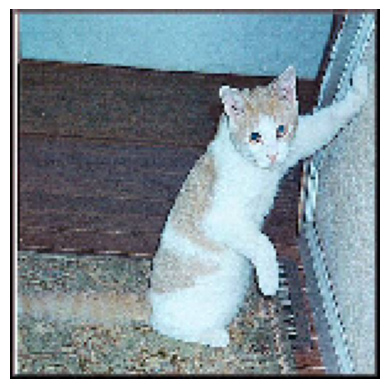

Prediction: 🐶 Dog (Raw Score: 0.9629)


In [19]:
test_cat_path = os.path.join(test_dir, "cats", os.listdir(os.path.join(test_dir, "cats"))[0])

img = image.load_img(test_cat_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

prediction = model.predict(img_array)

plt.imshow(img)
plt.axis("off")
plt.show()

label = "🐶 Dog" if prediction[0][0] > 0.5 else "🐱 Cat"
print(f"Prediction: {label} (Raw Score: {prediction[0][0]:.4f})")

## Test Individual Prediction (Dogs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


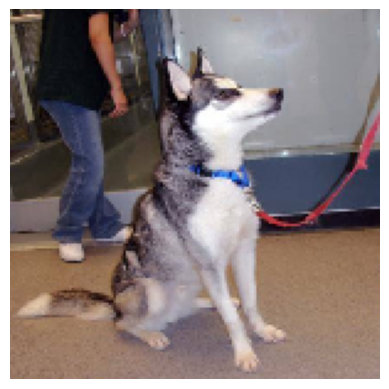

Prediction: 🐶 Dog (Raw Score: 0.8079)


In [20]:
test_dog_path = os.path.join(test_dir, "dogs", os.listdir(os.path.join(test_dir, "dogs"))[0])

img = image.load_img(test_dog_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

prediction = model.predict(img_array)

plt.imshow(img)
plt.axis("off")
plt.show()

label = "🐶 Dog" if prediction[0][0] > 0.5 else "🐱 Cat"
print(f"Prediction: {label} (Raw Score: {prediction[0][0]:.4f})")

In [21]:
# Evaluate model on the test dataset
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"\n📊 Final Test Loss: {test_loss:.4f}")
print(f"🎯 Final Test Accuracy: {test_accuracy * 100:.2f}%")

64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.7830 - loss: 0.4635

📊 Final Test Loss: 0.4635
🎯 Final Test Accuracy: 78.30%



📋 Classification Report:
              precision    recall  f1-score   support

     Cat (0)       0.78      0.78      0.78      1011
     Dog (1)       0.78      0.78      0.78      1012

    accuracy                           0.78      2023
   macro avg       0.78      0.78      0.78      2023
weighted avg       0.78      0.78      0.78      2023



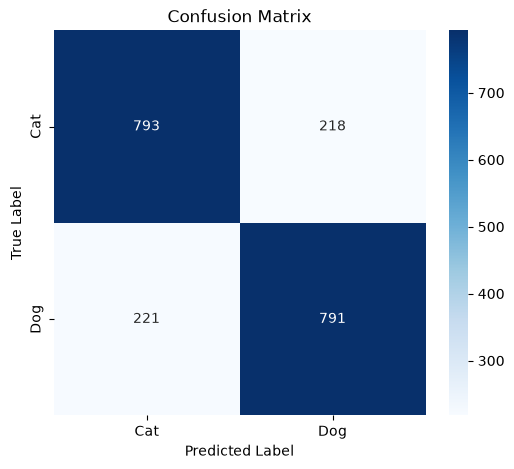

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Collect all true labels and predictions from the test dataset
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Print Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Cat (0)', 'Dog (1)']))

# Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cat', 'Dog'], 
            yticklabels=['Cat', 'Dog'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [26]:
# 1. Print Final Accuracies Side-by-Side
train_loss, train_acc = model.evaluate(train_dataset, verbose=0)
test_loss, test_acc = model.evaluate(test_dataset, verbose=0)

print(f"🏋️ Training Accuracy:  {train_acc * 100:.2f}%")
print(f"🧪 Testing Accuracy:   {test_acc * 100:.2f}%")

# Check for Overfitting Gap
gap = (train_acc - test_acc) * 100
if gap > 10:
    print(f"\n⚠️ Potential Overfitting Detected! Gap is {gap:.2f}%")
else:
    print(f"\n✅ Good fit! The gap is only {gap:.2f}%")

🏋️ Training Accuracy:  77.84%
🧪 Testing Accuracy:   78.30%

✅ Good fit! The gap is only -0.46%


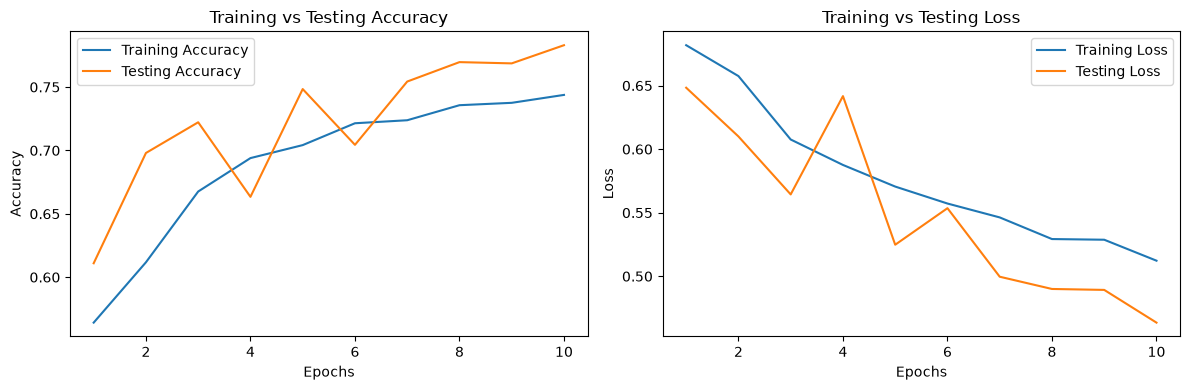

In [27]:
# 2. Visual Plot of Training vs Testing over Epochs
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Testing Accuracy')
plt.title('Training vs Testing Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Testing Loss')
plt.title('Training vs Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()